# QF 627 Programming and Computational Finance
## Problem Set 2 | `Questions`

### <font color = green> Activation of necessary libraries. </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### <font color = "blue"> `IMPORT` your dataset: `bank_loan.csv`. </font>

In [2]:
df =\
(
    pd.read_csv("bank_loan.csv")
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/566581184.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("bank_loan.csv")


In [3]:
## Above warning is due to mixed types in columns
## find the column 47. Keep in mind pandas uses 0-based indexing
df.columns[47]

'next_pymnt_d'

In [4]:
## Observe the values
df[df.columns[47]].head(20)

0        NaN
1        NaN
2        NaN
3        NaN
4     Jun-16
5        NaN
6        NaN
7        NaN
8        NaN
9        NaN
10       NaN
11       NaN
12       NaN
13       NaN
14       NaN
15       NaN
16       NaN
17       NaN
18       NaN
19       NaN
Name: next_pymnt_d, dtype: object

In [5]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717.000000,3.971700e+04,39717.000000,39717.000000,39717.000000,...,0.0,0.0,0.0,0.0,39020.000000,39678.0,0.0,0.0,0.0,0.0
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,324.561922,6.896893e+04,13.315130,0.146512,0.869200,...,NaN,NaN,NaN,NaN,0.043260,0.0,NaN,NaN,NaN,NaN
std,2.106941e+05,2.656783e+05,7456.670694,7187.238670,7128.450439,208.874874,6.379377e+04,6.678594,0.491812,1.070219,...,NaN,NaN,NaN,NaN,0.204324,0.0,NaN,NaN,NaN,NaN
min,5.473400e+04,7.069900e+04,500.000000,500.000000,0.000000,15.690000,4.000000e+03,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
25%,5.162210e+05,6.667800e+05,5500.000000,5400.000000,5000.000000,167.020000,4.040400e+04,8.170000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
50%,6.656650e+05,8.508120e+05,10000.000000,9600.000000,8975.000000,280.220000,5.900000e+04,13.400000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
75%,8.377550e+05,1.047339e+06,15000.000000,15000.000000,14400.000000,430.780000,8.230000e+04,18.600000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
max,1.077501e+06,1.314167e+06,35000.000000,35000.000000,35000.000000,1305.190000,6.000000e+06,29.990000,11.000000,8.000000,...,NaN,NaN,NaN,NaN,2.000000,0.0,NaN,NaN,NaN,NaN


In [6]:
## too many columns, see if we can get a transposed and viewable version
df.iloc[0].T

id                            1077501
member_id                     1296599
loan_amnt                        5000
funded_amnt                      5000
funded_amnt_inv                4975.0
                               ...   
tax_liens                         0.0
tot_hi_cred_lim                   NaN
total_bal_ex_mort                 NaN
total_bc_limit                    NaN
total_il_high_credit_limit        NaN
Name: 0, Length: 111, dtype: object

In [7]:
## lets see why there are so many columns
df.shape

(39717, 111)

### Question 1. Data `Inspection`

#### Question 1.1. How would you look at the first few rows of the DF?

In [8]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


#### Question 1.2. How would you look at all the column names?

In [9]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

In [10]:
## cant see the columns, try this
[ x for x in df.columns]

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

### Question 2. Data `Wrangling`

#### Question 2.1. How would you check the number of missing values in each column?

In [11]:
df.isna().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                        39
tot_hi_cred_lim               39717
total_bal_ex_mort             39717
total_bc_limit                39717
total_il_high_credit_limit    39717
Length: 111, dtype: int64

In [12]:
## above wont show all NA columns
[x for x in df.isna().sum()]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 2459,
 1075,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 12942,
 0,
 11,
 0,
 0,
 0,
 0,
 0,
 0,
 25682,
 36931,
 0,
 0,
 0,
 50,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 71,
 0,
 38577,
 2,
 56,
 39717,
 0,
 0,
 39717,
 39717,
 39717,
 0,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 56,
 0,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 39717,
 697,
 39,
 39717,
 39717,
 39717,
 39717]

> There are columns have a large number of missing values 

> Let's clean them first.

#### Question 2.2. How would you find the percentage of missing values in each column? 
> Hint: Use the missing values and divide it by something.

In [13]:
[ round(x) for x in df.isna().sum() / df.shape[0] * 100 ]
# [ round(x) for x in df.isna().sum() / len(df) * 100 ]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 6,
 3,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 33,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 65,
 93,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 97,
 0,
 0,
 100,
 0,
 0,
 100,
 100,
 100,
 0,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 0,
 0,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 2,
 0,
 100,
 100,
 100,
 100]

#### Question 2.3. How would you remove the columns having more than 90% missing values?

In [14]:
## use formula 
## (No. of NA values / total # of rows) * 100

null_90 =\
[ False if x > 90 else True for x in df.isna().sum() / df.shape[0] * 100 ]

In [15]:
## preview the resulting df with columns having less than 90% null values

df.loc[:, null_90]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,171.62,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,119.66,Sep-13,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,649.91,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,357.48,Apr-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,67.79,May-16,0.0,1,INDIVIDUAL,0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,92187,92174,2500,2500,1075.0,36 months,8.07%,78.42,A,A4,...,80.90,Jun-10,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39713,90665,90607,8500,8500,875.0,36 months,10.28%,275.38,C,C1,...,281.94,Jul-10,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39714,90395,90390,5000,5000,1325.0,36 months,8.07%,156.84,A,A4,...,0.00,Jun-07,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN
39715,90376,89243,5000,5000,650.0,36 months,7.43%,155.38,A,A2,...,0.00,Jun-07,NaN,1,INDIVIDUAL,0,NaN,0,NaN,NaN


In [16]:
sum(null_90)

55

> Let's check the number of missing values again.

In [17]:
df_null_90 =\
      df.loc[:, null_90]

sum([ x > 90 for x in df_null_90.isna().sum() / df_null_90.shape[0] * 100 ])

0

#### Question 2.4. How would you remove columns having more than 30% of missing values?
> Hint: With so **few** columns with more than 30% missing values, can you `drop` them by **name**?

In [18]:
df.shape

(39717, 111)

In [19]:
## similarly for 30%
null_30 =\
[ True if x > 30 else False for x in df.isna().sum() / df.shape[0] * 100 ]

In [20]:
## we can get the col names with df.columns
cols_to_drop =\
(
      df.columns[null_30]
)

In [21]:
df_null_30 =\
(
    df.drop(columns=cols_to_drop)  # drop the column names with more than 30% null values
) 

> Let's check number of missing values again, does all columns have **less than** 90% missing values?

In [22]:
df_null_30.isna().sum()

id                               0
member_id                        0
loan_amnt                        0
funded_amnt                      0
funded_amnt_inv                  0
term                             0
int_rate                         0
installment                      0
grade                            0
sub_grade                        0
emp_title                     2459
emp_length                    1075
home_ownership                   0
annual_inc                       0
verification_status              0
issue_d                          0
loan_status                      0
pymnt_plan                       0
url                              0
purpose                          0
title                           11
zip_code                         0
addr_state                       0
dti                              0
delinq_2yrs                      0
earliest_cr_line                 0
inq_last_6mths                   0
open_acc                         0
pub_rec             

In [23]:
## create a boolean list for columns with more than 30% null values in df_null_30
bool_cols_df_null_30 =\
[ True if x > 30 else False for x in df.isna().sum() / df_null_30.shape[0] * 100 ]

sum(bool_cols_df_null_30)

58

In [24]:
## Alternative approach
# Calculate the percentage of nulls per column
null_percent = df.isna().mean() * 100

# Create a boolean Series for columns with more than 30% nulls
bool_cols_df_null_30 = null_percent > 30

# To get the count
bool_cols_df_null_30.sum()

np.int64(58)

#### Question 2.5. How would you check missing values rows-wise, by the way?
> Hint: What does the `axis` argument do?

In [25]:
## set the df to df_null_30
df =\
(
    df_null_30
)     

In [26]:
df.shape
## we reduce the cols from 111 to 53

(39717, 53)

In [27]:
df.isnull?

Signature: df.isnull() -> 'DataFrame'
Docstring:
DataFrame.isnull is an alias for DataFrame.isna.

Detect missing values.

Return a boolean same-sized object indicating if the values are NA.
NA values, such as None or :attr:`numpy.NaN`, gets mapped to True
values.
Everything else gets mapped to False values. Characters such as empty
strings ``''`` or :attr:`numpy.inf` are not considered NA values
(unless you set ``pandas.options.mode.use_inf_as_na = True``).

Returns
-------
DataFrame
    Mask of bool values for each element in DataFrame that
    indicates whether an element is an NA value.

See Also
--------
DataFrame.isnull : Alias of isna.
DataFrame.notna : Boolean inverse of isna.
DataFrame.dropna : Omit axes labels with missing values.
isna : Top-level isna.

Examples
--------
Show which entries in a DataFrame are NA.

>>> df = pd.DataFrame(dict(age=[5, 6, np.nan],
...                        born=[pd.NaT, pd.Timestamp('1939-05-27'),
...                              pd.Timestamp('1

In [28]:
## use isna() to sum the nulls in each row
df.isna().sum(axis=1)

0        1
1        0
2        1
3        0
4        0
        ..
39712    4
39713    4
39714    5
39715    5
39716    4
Length: 39717, dtype: int64

> How would you check whether some rows have more than 5 missing values

In [29]:
## since we have the sum we can use a boolean condition to filter rows with more than 5 nulls
## we can do eyeball check with above results to validate
df.isna().sum(axis=1) > 5

0        False
1        False
2        False
3        False
4        False
         ...  
39712    False
39713    False
39714    False
39715    False
39716    False
Length: 39717, dtype: bool

In [30]:
sum(df.isna().sum(axis=1) > 5)

0

> The dataset is cleaned now; let's check whether all the columns are in the correct format or not.

In [31]:
df.dtypes

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                           object
int_rate                       object
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                     int64
earliest_cr_line               object
inq_last_6mt

> The column `int_rate` is character type, let's convert it to float.

In [32]:
# df['int_rate'] =\
(
    df['int_rate'].str.strip('%').astype(float)
)

0        10.65
1        15.27
2        15.96
3        13.49
4        12.69
         ...  
39712     8.07
39713    10.28
39714     8.07
39715     7.43
39716    13.75
Name: int_rate, Length: 39717, dtype: float64

#### Question 2.6. How would you use `lambda` to convert the data type of `int_rate`?

In [33]:
df['int_rate'] =\
(
    df['int_rate'].apply(lambda x: float(x.strip('%')))
)

> Let's check the data types again.

In [34]:
df.dtypes

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                     int64
earliest_cr_line               object
inq_last_6mt

> Lets extract the numeric part from the variable employment length.

> First, let's drop the missing values from the column (otherwise the regex code below throws error) using regular expression to extract numeric values from the string convert to numeric

In [35]:
## we see emp_length is a string object
df['emp_length']

0        10+ years
1         < 1 year
2        10+ years
3        10+ years
4           1 year
           ...    
39712      4 years
39713      3 years
39714     < 1 year
39715     < 1 year
39716     < 1 year
Name: emp_length, Length: 39717, dtype: object

In [36]:
## when using value counts we need to dropna to see the values
df['emp_length'].value_counts(), df['emp_length'].value_counts(dropna=False)

(emp_length
 10+ years    8879
 < 1 year     4583
 2 years      4388
 3 years      4095
 4 years      3436
 5 years      3282
 1 year       3240
 6 years      2229
 7 years      1773
 8 years      1479
 9 years      1258
 Name: count, dtype: int64,
 emp_length
 10+ years    8879
 < 1 year     4583
 2 years      4388
 3 years      4095
 4 years      3436
 5 years      3282
 1 year       3240
 6 years      2229
 7 years      1773
 8 years      1479
 9 years      1258
 NaN          1075
 Name: count, dtype: int64)

In [37]:
## lets see if all NaN emp_length values have a corresponding emp_title
df[['emp_length','emp_title']].groupby(['emp_length','emp_title'],dropna=False).count().tail(20)

Empty DataFrame
Columns: []
Index: [(nan, Psomas), (nan, Retired), (nan, Ryla Teleservices), (nan, Sauder Woodworking), (nan, Tong Parks), (nan, Tucker Rocky Distribution), (nan, US Army National Guard), (nan, US Government ), (nan, USAF), (nan, Unite Food and Commercial Workers), (nan, VA Health Care Hospital), (nan, Vanilla Urban Threads), (nan, Vista Verde Middle School), (nan, Yale Long Insurance), (nan, air force), (nan, ft lewis), (nan, penny marketing), (nan, retired), (nan, us army national guard), (nan, nan)]

In [38]:
## seems that emp_length is NaN even as there is an emp_title
## should we consider dropping all NaN rows?
## we decided to keep them but ensure we handle emp_length properly when plotting or doing analysis

## lets see how we can use re search to extract the number of years of emp_length
import re
re.search?

Signature: re.search(pattern, string, flags=0)
Docstring:
Scan through string looking for a match to the pattern, returning
a Match object, or None if no match was found.
File:      /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/re/__init__.py
Type:      function

In [39]:
## do a trial run with one of the non-null values
re.search(r'\d+',  df['emp_length'].iloc[200])[0]

'5'

In [40]:
df['emp_length'] =\
(
    df['emp_length']\
    .dropna()\
    .apply(
        lambda x: int(re.search(r'\d+', str(x))[0]) if pd.notnull(x) and re.search(r'\d+', str(x)) else pd.NA
    )
)

In [41]:
df['emp_length'].value_counts(dropna=False)

emp_length
10.0    8879
1.0     7823
2.0     4388
3.0     4095
4.0     3436
5.0     3282
6.0     2229
7.0     1773
8.0     1479
9.0     1258
NaN     1075
Name: count, dtype: int64

> Let's take a look at type of the columns again

In [42]:
df.dtypes

id                              int64
member_id                       int64
loan_amnt                       int64
funded_amnt                     int64
funded_amnt_inv               float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                    float64
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                     int64
earliest_cr_line               object
inq_last_6mt

In [43]:
df.shape

(39717, 53)

In [44]:
loan = df

In [45]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  float64
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

### Question 3. Exploratory Data Analysis (EDA)

> There are some variables not available at the time of loan application, and thus they cannot be used as predictors for credit approval. 

In [46]:
variables_to_remove = [
  "delinq_2yrs",
  "earliest_cr_line",
  "inq_last_6mths",
  "open_acc",
  "pub_rec",
  "revol_bal",
  "revol_util",
  "total_acc",
  "out_prncp",
  "out_prncp_inv",
  "total_pymnt",
  "total_pymnt_inv",
  "total_rec_prncp",
  "total_rec_int",
  "total_rec_late_fee",
  "recoveries",
  "collection_recovery_fee",
  "last_pymnt_d",
  "last_pymnt_amnt",
  "last_credit_pull_d",
  "application_type"]

variables_to_remove

['delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'application_type']

#### Question 3.1. How would you remove the set of variables from `variables_to_remove` from the dataset?

In [47]:
loans_eda =\
(   
    loan.drop(columns=variables_to_remove)
)
loans_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  float64
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

#### Question 3.2. Are there any other variables that we can remove from the dataset also?

-  Also, we won't use the variables zip code, address, state etc. 
-  The variable `title` is derived from the variable `purpose` thus let get rid of all these variables as well

In [48]:
# remove redundant variables
loans_eda.drop(columns=['title'], inplace=True)

Other redundant variables
- sub grade is related to grade

In [49]:
loans_eda.drop(columns=['sub_grade'], inplace=True)

In [50]:
# remove address related
loans_eda.drop(columns=['zip_code','addr_state', 'url'], inplace=True)

In [51]:
# remove ids and unique identifiers
loans_eda.drop(columns=['id','member_id'], inplace=True)

In [52]:
(
    loans_eda
    .describe()
    .loc['std']
    .sort_values()
)

collections_12_mths_ex_med        0.000000
policy_code                       0.000000
acc_now_delinq                    0.000000
chargeoff_within_12_mths          0.000000
delinq_amnt                       0.000000
tax_liens                         0.000000
pub_rec_bankruptcies              0.204324
emp_length                        3.408338
int_rate                          3.724825
dti                               6.678594
installment                     208.874874
funded_amnt_inv                7128.450439
funded_amnt                    7187.238670
loan_amnt                      7456.670694
annual_inc                    63793.765790
Name: std, dtype: float64

In [53]:
zero_var_cols =\
(
    loans_eda
    .describe()
    .loc['std']
    .sort_values()
    [lambda x: x == 0.0]
    .index
    .tolist()
)
zero_var_cols
# double checck this later

['collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'tax_liens']

In [54]:
loans_eda['policy_code'].unique()

array([1])

In [55]:
# we can remove these
loans_eda.drop(columns=zero_var_cols, inplace=True)
loans_eda.head(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,initial_list_status,pub_rec_bankruptcies
0,5000,5000,4975.0,36 months,10.65,162.87,B,NaN,10.0,RENT,24000.0,Verified,Dec-11,Fully Paid,n,credit_card,27.65,f,0.0
1,2500,2500,2500.0,60 months,15.27,59.83,C,Ryder,1.0,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,car,1.00,f,0.0
2,2400,2400,2400.0,36 months,15.96,84.33,C,NaN,10.0,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,small_business,8.72,f,0.0
3,10000,10000,10000.0,36 months,13.49,339.31,C,AIR RESOURCES BOARD,10.0,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,other,20.00,f,0.0
4,3000,3000,3000.0,60 months,12.69,67.79,B,University Medical Group,1.0,RENT,80000.0,Source Verified,Dec-11,Current,n,other,17.94,f,0.0


In [56]:
# check non-numeric columns
for col in loans_eda.select_dtypes(exclude=[np.number]).columns: # exlude numeric columns
    print(f"{col}: {loans_eda[col].nunique(dropna=False)} unique values")

term: 2 unique values
grade: 7 unique values
emp_title: 28821 unique values
home_ownership: 5 unique values
verification_status: 3 unique values
issue_d: 55 unique values
loan_status: 3 unique values
pymnt_plan: 1 unique values
purpose: 14 unique values
initial_list_status: 1 unique values


In [57]:
# remove constant values
loans_eda.drop(columns=['pymnt_plan','initial_list_status'], inplace=True)

In [58]:
loans_eda.columns.to_list()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'dti',
 'pub_rec_bankruptcies']

In [59]:
loans_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             39717 non-null  int64  
 1   funded_amnt           39717 non-null  int64  
 2   funded_amnt_inv       39717 non-null  float64
 3   term                  39717 non-null  object 
 4   int_rate              39717 non-null  float64
 5   installment           39717 non-null  float64
 6   grade                 39717 non-null  object 
 7   emp_title             37258 non-null  object 
 8   emp_length            38642 non-null  float64
 9   home_ownership        39717 non-null  object 
 10  annual_inc            39717 non-null  float64
 11  verification_status   39717 non-null  object 
 12  issue_d               39717 non-null  object 
 13  loan_status           39717 non-null  object 
 14  purpose               39717 non-null  object 
 15  dti                

#### Question 3.3. Let's have a look at the target variable--`loan_status`. 

> Objecive: Re-label the values to a `binary form`: namely, `0` or `1`, 
>
> - 1 indicating that the person has defaulted and 
> - 0 otherwise.

But first, what makes up the target variable--`loan_status`?

In [60]:
loans_eda['loan_status'].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

> You should be able to see that `fully paid` comprises most of the loans. 

> The ones marked `current` are neither fully paid not defaulted, so let's get rid of the current loans. 

> Hence, we will have two categories to label as 0 or 1.

- Filter for `Fully Paid` and `Charged Off` 
- Using `lambda`, let's label `Fully Paid` and `Charged Off`

In [61]:
loans_eda_without_current = loans_eda.query("loan_status == 'Fully Paid' or loan_status == 'Charged Off'")

In [62]:
loans_eda_without_current['loan_status'].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Name: count, dtype: int64

> Let's convert `loan_status` to **integer data type** (again, use `lambda`).

In [63]:
loans_eda_without_current['loan_status'] =\
(
    loans_eda_without_current['loan_status']
    .apply(lambda x: 1 if x == 'Charged Off' else 0)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1595359232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loans_eda_without_current['loan_status'] =\


In [64]:
loans_eda_without_current['loan_status'].info()

<class 'pandas.core.series.Series'>
Index: 38577 entries, 0 to 39716
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
38577 non-null  int64
dtypes: int64(1)
memory usage: 602.8 KB


> Let's take a look at the data points under the `loan_status` category.

In [65]:
loans_eda_without_current['loan_status'].value_counts()

loan_status
0    32950
1     5627
Name: count, dtype: int64

### Question 4. A Simple Univariate Analysis

In [66]:
df_Q4 = loans_eda_without_current.copy()

> First, let's look at the overall default rate.

#### Question 4.1. How would you calculate default rate? Please use `numpy` module.

In [67]:
# df_Q4.loan_status.sum() / df_Q4.shape[0]
df_Q4.loan_status.mean()

np.float64(0.14586411592399617)

> The overall default rate is about `14.6%`.  

> Let's visualize default rates across grade of the loan.

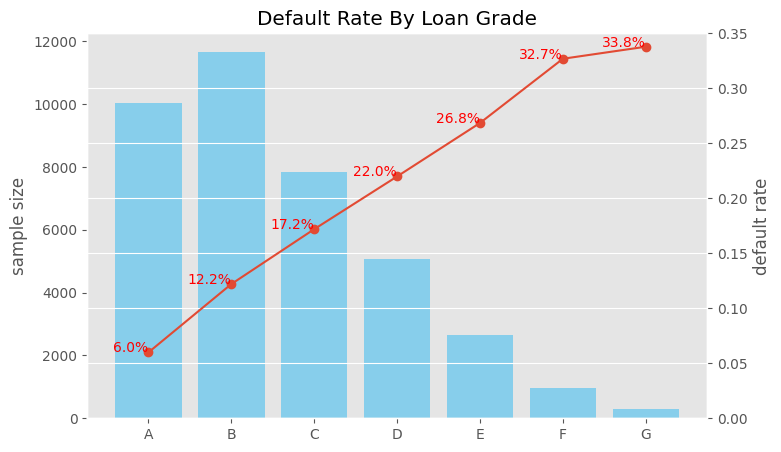

In [68]:
plt.style.use('ggplot')

default_rate_by_grade =\
(
    df_Q4
    .groupby("grade")
    .agg(
        default_rate=("loan_status", "mean")
        , sample_size=("loan_status", "count")
    )
)

fig, ax = plt.subplots(
    figsize=(8,5)
)
ax.bar(
    default_rate_by_grade.index
    , default_rate_by_grade["sample_size"]
    , label = "sample size"
    , color = "skyblue"
)
ax.set_ylabel("sample size")
ax.grid(False)
ax2 = ax.twinx()
ax2.plot(
    default_rate_by_grade.index
    , default_rate_by_grade["default_rate"]
    , label = "default rate"
    , marker = 'o'
)
ax2.set_ylabel("default rate")
ax2.set_ylim(0, 0.35) # for easier comparison across different categorical variables
for x, y in zip(default_rate_by_grade.index, default_rate_by_grade["default_rate"]):
    ax2.annotate(
        f"{y:.1%}", (x, y)
        , ha="right"
        , color="red"
    )
plt.title("Default Rate By Loan Grade")
plt.show()

#### Question 4.2. Create a function to plot `loan_status` across `any categorical variable`.
> Hint: How did you visualise in Question 4.1? Is there a way to generalise what you did for `any categorical variable`?

In [69]:
def plot_default_rate_by(input_df
                         , cat_col
                         , label_col = "loan_status"
                         , sort_by = None
                         ):
    # check inputs
    required_cols = [cat_col, label_col]
    missing_cols = list(set(input_df.columns) - set(required_cols))
    assert set(required_cols).issubset(input_df.columns), f"Column(s) {missing_cols} not found."
    
    # calc default rate
    res =\
    (
        input_df
        .groupby(cat_col, observed=False)
        .agg(
            default_rate=("loan_status", "mean")
            , sample_size=("loan_status", "count")
        )
    )
    if sort_by == cat_col:
        res = res.sort_index()
    elif sort_by in ["sample_size", "default_rate"]:
        res = res.sort_values(by=sort_by)
    # plot
    fig, ax = plt.subplots(
        figsize=(8,5)
    )
    ax.bar(
        res.index
        , res["sample_size"]
        , label = "sample size"
        , color = "skyblue"
    )
    ax.set_ylabel("sample size")
    ax.grid(False)
    ax2 = ax.twinx()
    ax2.plot(
        res.index
        , res["default_rate"]
        , label = "default rate"
        , marker = 'o'
    )
    ax2.set_ylabel("default rate")
    ax2.set_ylim(0, 0.35) # for easier comparison across different categorical variables
    for x, y in zip(res.index, res["default_rate"]):
        ax2.annotate(
            f"{y:.1%}", (x, y)
            , ha="right"
            , color="red"
        )
    fig.autofmt_xdate() 
    plt.title(f"Default Rate By {cat_col}")
    plt.show()

#### How's default rates across `grade` of loan? Use your newly created function :)

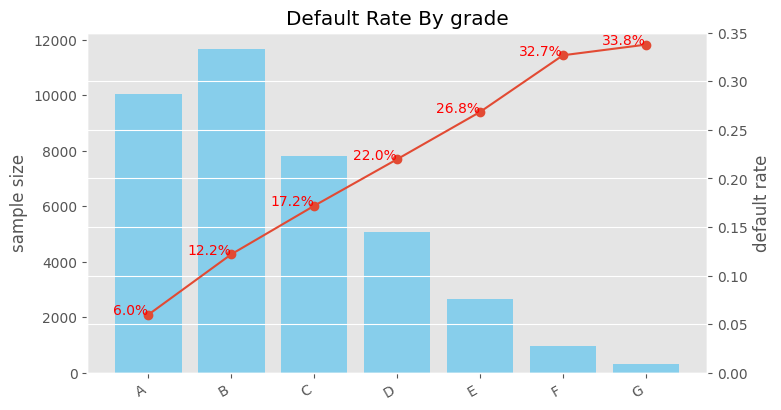

In [70]:
plot_default_rate_by(df_Q4, "grade")

> What is your `interpretation`?

> A:

> The variable grade has good distinguishing power on default rate. As we can see from the graph, default rates rise monotonically and significantly accoss different grades, from 6% at grade A to 33.8% at grade G. Although the default rates of grade F and G might be statistically unstable due to the small sample size.

#### `term`

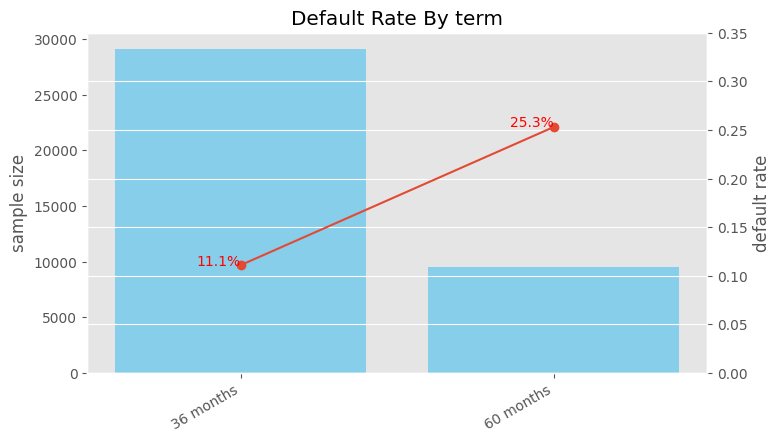

In [71]:
plot_default_rate_by(df_Q4, "term")

> What is your `interpretation`?

> A:

> The variable term can be seen as one of the factors of default rate. Based on the above result, we know that 60-month loans have significantly higher possibility of default comparing to 36-month loans, hence should require more conservative credit policy and higher compensation.

> But we can't conclude that there is correlation between longer loan terms and higher default rates as the data is limited. If the bank offers product with a different term other than 36 and 60 months, default rate should be assessed separately.

#### `home_ownership`

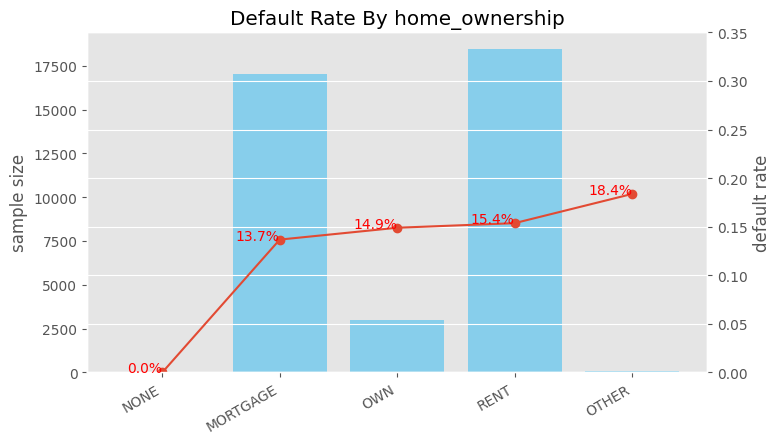

In [72]:
plot_default_rate_by(df_Q4, "home_ownership", sort_by="default_rate")

> What is your `interpretation`?

> A:

> We can ignore the "NONE" and "OTHER" category due to small sample size. Among the remaining three categories, the default rates are very close to each other and the overall average value. So the variable home_ownership doesn't show much distinguish power here.

#### The role of `verification_status`?

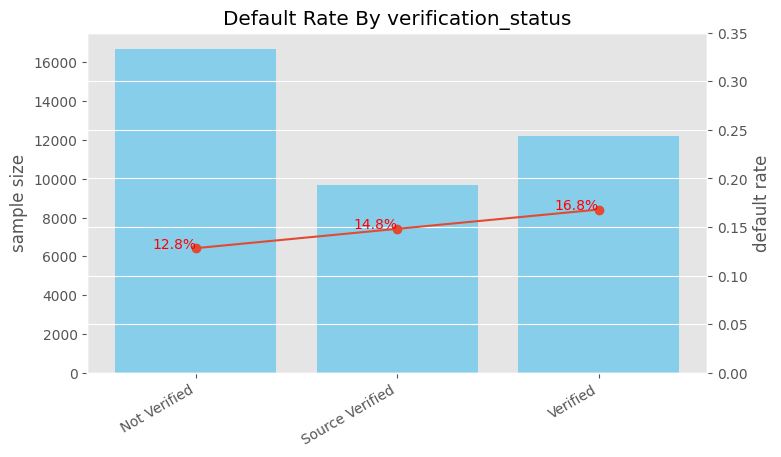

In [73]:
plot_default_rate_by(df_Q4, "verification_status")

> What is your `interpretation`? 

> A:

> There is only 2% difference in default rate between each adjacent category. The variable verification_status might be a very weak factor. It takes further examination to tell whether the differences are statistically significant or not.

#### The role of Loan `purpose`?

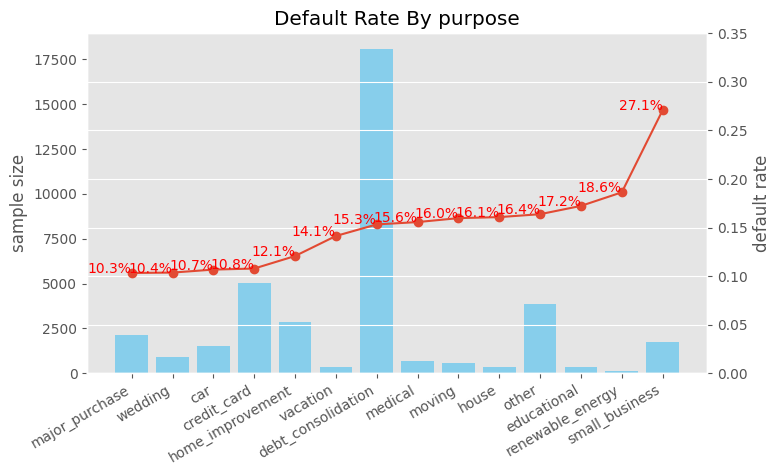

In [74]:
plot_default_rate_by(df_Q4, "purpose", sort_by="default_rate")

> What is your `interpretation`?

> A:

> The sample sizes across categories are highly imbalanced, with very large groups like "debt_consolidation" (18055 loans) and very tiny groups like "renewable energy" (102 loans). For "small_business" and "credit_card", the large gaps in default rate comparing to the overall average probably have statistical significance, whereas others need further examination to tell. If this variable is to be used in predictive modeling, a tiered regrouping (by merging similar risk level categories like "car", "credit_card", "major_purchase" and "wedding") might improve stability and give higher distinguishing power.

#### Question 4.3. How is the distribution of loans across time?

> Please convert the column `issue_d` into datetime and then extract year and month from it.

In [75]:
df_Q4["issue_d"] =\
(
    pd.to_datetime(df_Q4["issue_d"]
                   , format="%b-%y")
)

> Yes, please use `lambda`.

> Please extract month and year from `issue_d`, using `lambda`.

In [76]:
df_Q4['issue_y'] =\
(
    df_Q4["issue_d"]
    .dt
    .year
)

df_Q4['issue_m'] =\
(
    df_Q4["issue_d"]
    .dt
    .month
)

> How would you examine the number of loans granted across `years`?

In [77]:
(
    df_Q4['issue_y']
    .value_counts()
)

issue_y
2011    20516
2010    11532
2009     4716
2008     1562
2007      251
Name: count, dtype: int64

You can see that the number of loans has increased steadily across years. 

> How would you examine the number of loans across months?

In [78]:
(
    df_Q4['issue_m']
    .value_counts()
    .sort_index()
)

issue_m
1     2379
2     2358
3     2691
4     2831
5     2919
6     3180
7     3351
8     3388
9     3498
10    3761
11    4006
12    4215
Name: count, dtype: int64

> `Interpretation`?

> A:

> The number of loans increases from Jan to Dec.  On average, the last quarter contributes more than 30% to the total number of loans throughout a year.

#### Compare the default rates across years.

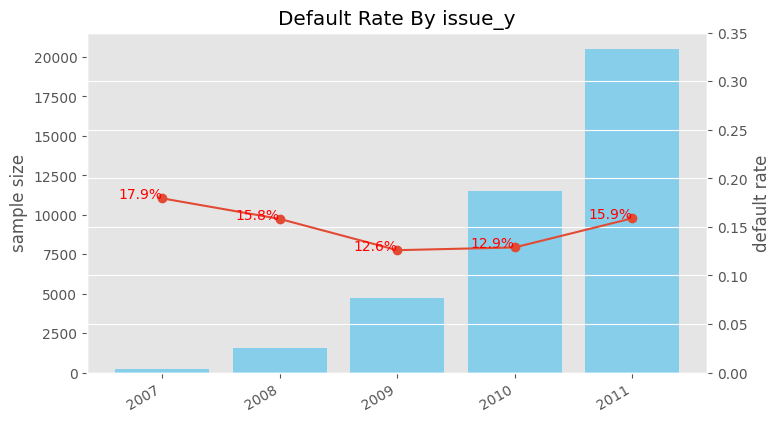

In [79]:
plot_default_rate_by(df_Q4, "issue_y")

> `Interpretation`?

> A:

> For 2007 and 2008, there isn't much to tell due to the small sample size. Starting from 2009, default rate is not always stable, it can be fluctuated across different years, influenced by ecnomic regime, bank's risk appetite or else. So time should be taken into consideration for default rate analysis.

#### Let's compare default rates across months.

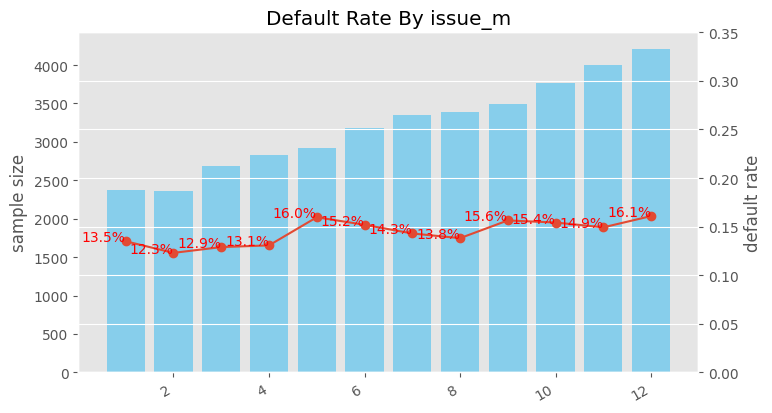

In [80]:
plot_default_rate_by(df_Q4, "issue_m")

> `Interpretation`? 

> A:

> Seems May and Dec have higher default rate comparing to other months.

#### Question 4.4. Let's now analyse how the default rate varies across continuous variables.

> Loan Amount: `loan_amnt`

In [81]:
# def plot_default_rate_by_bin(input_df, continuous_var, bin_num=10):
#     assert continuous_var in input_df.columns, f"Column {continuous_var} not found."
#     temp_df =\
#         input_df[[
#             "loan_status", 
#             continuous_var
#         ]].copy()
#     temp_df[f"{continuous_var}_bin"] =\
#         pd.qcut(
#             input_df[continuous_var],
#             q=bin_num
#         )
#     default_rate_groupby_bin =\
#     (
#         temp_df
#         .groupby(f"{continuous_var}_bin")
#         .loan_status
#         .sum() 
#         / (
#             temp_df
#             [f"{continuous_var}_bin"]
#             .value_counts()
#         )
#     )

#     default_rate_groupby_bin.plot(
#         kind='bar',
#         title=f'Default Rate By {continuous_var} (bin_num={bin_num})'
#     )
#     plt.ylabel("Default Rate")
#     plt.show()

In [82]:
# default_rate_by_loan_amnt =\
(
    df_Q4
    .groupby("loan_amnt")
    .agg(
        default_rate=("loan_status", "mean")
        , sample_size=("loan_status", "count")
    ).sort_values(
        by="sample_size"
        , ascending=False
    )
)

,default_rate,sample_size
loan_amnt,,
10000,0.128871,2809
12000,0.134786,2248
5000,0.141519,2028
6000,0.112937,1886
15000,0.140914,1838
...,...,...
19450,0.000000,1
19475,1.000000,1
19550,0.000000,1


> `Interpretation`?

> A:

> For continuous variable like "loan_ammt", if we also use the same way as we treat categorical variables, results will have too many categories with most of them having tiny sample size. One way to solve this is to bin the variable first.

> Another way to analyse how default rates vary across continous variables is to bin the variables into discrete categories.

> Let's create a categorical variable for the loan amount variable into small, medium, high, very high.

* loan_amount < 5000 `low`
* loan_amount >=5000 and loan_amount < 15000 `medium`
* loan_amount >= 15000 and loan_amount < 25000 `high`
* greater than 25000 `very high`

In [83]:
df_Q4["loan_amnt_bin"] =\
(
    pd.cut(
        df_Q4["loan_amnt"]
        , bins=[0, 5000, 15000, 25000, np.inf]
        , labels=["low", "medium", "high", "very high"]
        , right=False
    )
)
df_Q4\
    .groupby("loan_amnt_bin", observed=False)\
    ["loan_amnt"]\
    .agg(['min','max','count'])

,min,max,count
loan_amnt_bin,,,
low,500,4975,7444
medium,5000,14975,20675
high,15000,24975,7696
very high,25000,35000,2762


In [84]:
# alternative way to create bins
bins = [5000, 15000, 25000]
labels = np.array(["low", "medium", "high", "very high"])
alternative_loan_amnt_bin =\
(
    df_Q4["loan_amnt"]
        .apply(
            lambda x: labels[
                np.searchsorted(
                    bins
                    ,x
                    ,side="right"
                )
            ]
        )
)
alternative_loan_amnt_bin.value_counts()

loan_amnt
medium       20675
high          7696
low           7444
very high     2762
Name: count, dtype: int64

> Let's compare the default rates across loan amount type

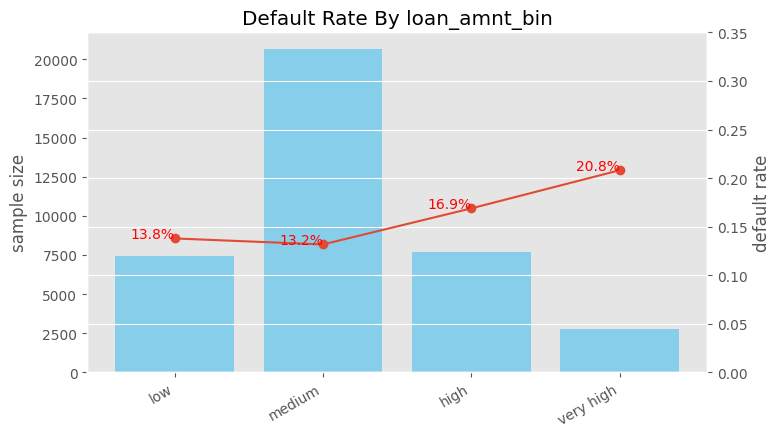

In [85]:
plot_default_rate_by(df_Q4, "loan_amnt_bin")

> `Interpretation`?

> A:

> The variable loan_amnt has some distinguishing power on default rate. For loans falling into "high" (>=15k) category, default rate increases by ~2.3% whereas for those in "very high" (>=25k) category, default rate increases by ~6.2%, comparing to the overall average.

#### Let's also convert funded amount invested to bins (using the same scheme from `loan_amount`)

In [86]:
df_Q4["funded_amnt_bin"] =\
(
    pd.cut(
        df_Q4["funded_amnt"],
        bins=[0, 5000, 15000, 25000, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=False
    )
)
df_Q4\
    .groupby("funded_amnt_bin", observed=False)\
    ["funded_amnt"]\
    .agg(['min','max','count'])

,min,max,count
funded_amnt_bin,,,
low,500,4975,7538
medium,5000,14975,21152
high,15000,24975,7539
very high,25000,35000,2348


> Visualize the results

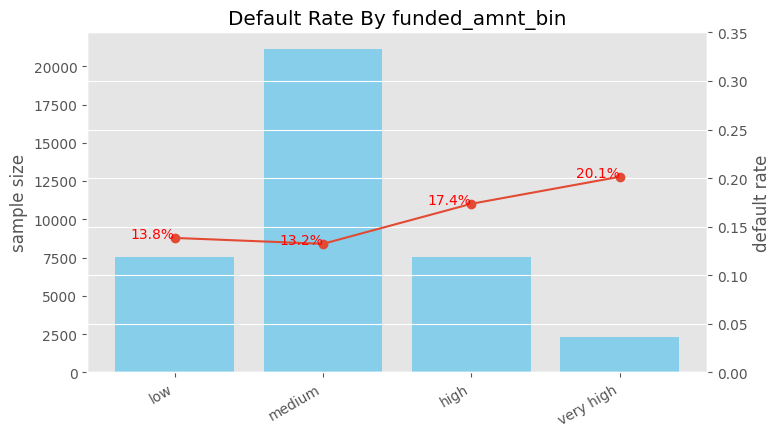

In [87]:
plot_default_rate_by(df_Q4, "funded_amnt_bin")

#### Interest Rate (int_rate)

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=15 `medium`
* greater than 15 `high`

> Use lambda for creating a new categorical variable.

In [88]:
df_Q4["int_rate_bin"] =\
(
    pd.cut(
        df_Q4["int_rate"],
        bins=[0, 10, 15, np.inf],
        labels=["low", "medium", "high"],
        right=True
    )
)
df_Q4\
    .groupby("int_rate_bin", observed=False)\
    ["int_rate"]\
    .agg(['min','max','count'])

,min,max,count
int_rate_bin,,,
low,5.42,10.00,12316
medium,10.01,14.96,18265
high,15.01,24.40,7996


> Let's compare default rates across rates of interest

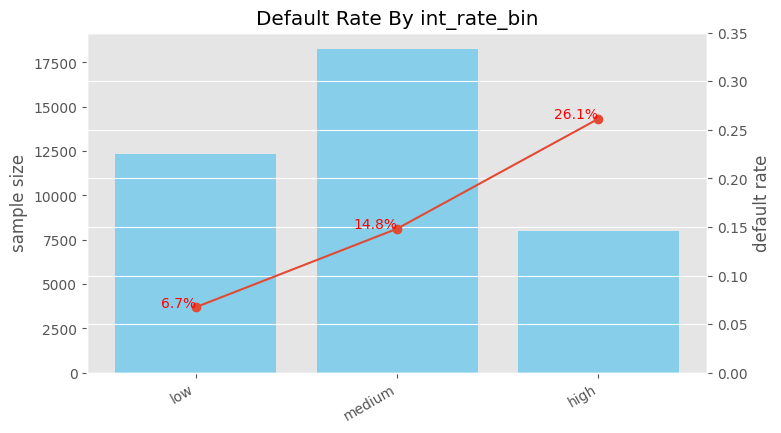

In [89]:
plot_default_rate_by(df_Q4, "int_rate_bin")

> `Interpretaion`?

> A:

> The variable int_rate has good distinguish power on default rate. As we can see from the graph, default rates rise monotonically and significantly accoss different int_rate bins, from 6.7% at low int_rate (<=10%) to 26.1% at high int_rate (>15%).

#### debt-to-income (`dti`) ratio

> Please create a categorical variable of `dti` using your own function

> Use the following definitions for each categories.

* <= 10 `low`
* dti > 10 and dti <=20 `medium`
* greater than 20 `high`

> Use lambda for creating a new variable.

In [90]:
df_Q4["dti_bin"] =\
(
    pd.cut(
        df_Q4["dti"],
        bins=[0, 10, 20, np.inf],
        labels=["low", "medium", "high"],
        right=True
    )
)
df_Q4\
    .groupby("dti_bin", observed=False)\
    ["dti"]\
    .agg(['min','max','count'])

,min,max,count
dti_bin,,,
low,0.01,10.00,12757
medium,10.01,20.00,18441
high,20.01,29.99,7201


> Let's comparing default rates across debt to income ratio

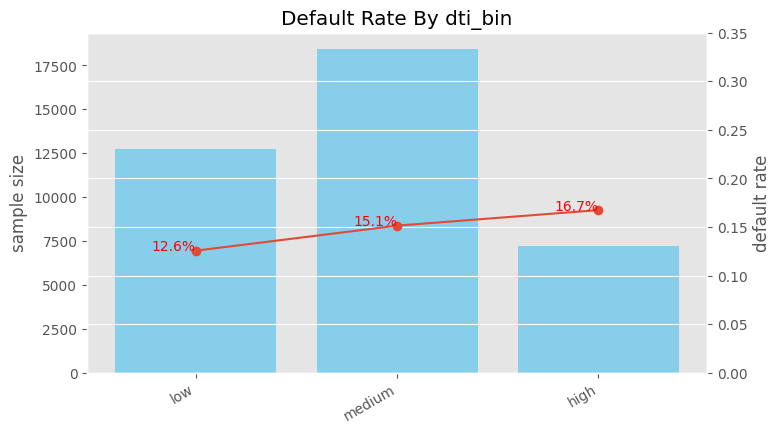

In [91]:
plot_default_rate_by(df_Q4, "dti_bin")

> `Interpretation`?

> A:

> The variable dti has some distinguish power on default rate but not as much as int_rate. The gap between the highest default rate (16.7%) and the lowest default rate (12.6%) among the categories is only 4.1%, comparing to ~20% for int_rate.

#### `funded_amount`

> Please create a categorical variable of `funded_amount` using your own function

> Use the following definitions for each categories.

- <= 5000 `low`
- funded_amount > 5000 and funded_amount <=15000 `medium`
- greater than 15000 `high`

> Use lambda for creating a new variable.

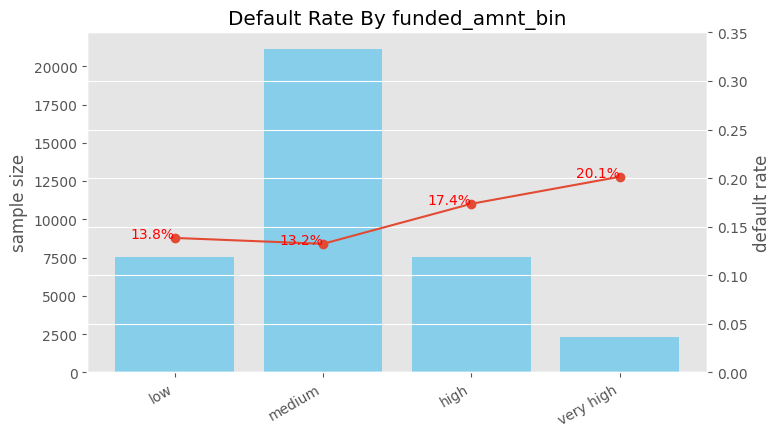

In [92]:
plot_default_rate_by(df_Q4, "funded_amnt_bin")

#### `installment`

> Please create a categorical variable of `installment` using your own function

> Use the following definitions for each categories.

- installment <= 200 `low`
- installment > 200 and installment <= 400 `medium`
- installment > 400 and installment <= 600 `high`
- greater than 600 = `very high`

> Use lambda for creating a new variable.

In [93]:
df_Q4["installment_bin"] =\
(
    pd.cut(
        df_Q4["installment"],
        bins=[0, 200, 400, 600, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=True
    )
)
df_Q4\
    .groupby("installment_bin", observed=False)\
    ["installment"]\
    .agg(['min','max','count'])

,min,max,count
installment_bin,,,
low,15.69,199.95,13074
medium,200.01,399.97,14732
high,400.04,599.99,6563
very high,600.03,1305.19,4208


> Let's compare default rates across installment

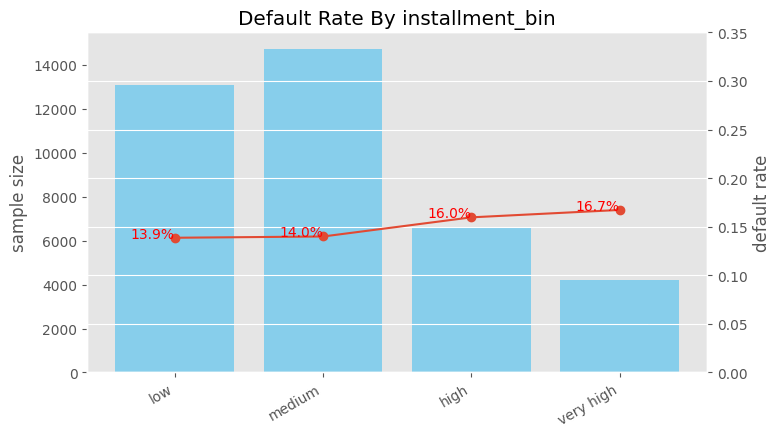

In [94]:
plot_default_rate_by(df_Q4, "installment_bin")

> `Interpretation`?

> A:

> There is not much distinguishing power in variable installment. The default rates in each category is quite close to each other.

#### How about `annual_income`? 

> Please create a categorical variable of annual_income using your own function

> Use the following definitions for each categories.

- less than or equal to 50k = `low`
- greater than 50k less than equal to 100 k = `medium`
- greater than 100k less than equal to 150k = `high`
- greater than 150k = `very high`

> Use lambda for creating a new variable.

In [95]:
df_Q4["annual_inc_bin"] =\
(
    pd.cut(
        df_Q4["annual_inc"],
        bins=[0, 50000, 100000, 150000, np.inf],
        labels=["low", "medium", "high", "very high"],
        right=True
    )
)
df_Q4\
    .groupby("annual_inc_bin", observed=False)\
    ["annual_inc"]\
    .agg(['min','max','count'])

,min,max,count
annual_inc_bin,,,
low,4000.00,50000.0,15389
medium,50000.04,100000.0,17707
high,100008.00,150000.0,3995
very high,150060.00,6000000.0,1486


> Visualize the results.

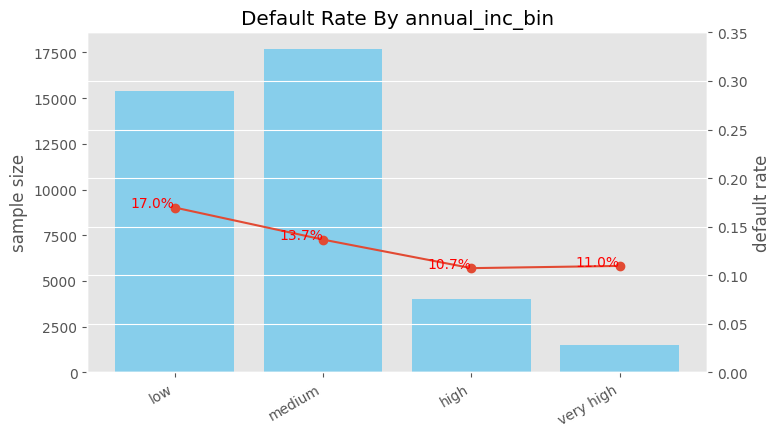

In [96]:
plot_default_rate_by(df_Q4, "annual_inc_bin")

> What's your interpretation?

> A:

> The variable annual_inc has some distinguishing power on default rate, with default rates in "low" and "high" category clearly deviate from the overall average. 

#### `Employment Length`

> First, let's drop the missing value observations in `emp_length`

> Please create a categorical variable of `emp_length` using your own function

> Use the following definitions for each categories.

* emp_length <= 1 `fresher`
* emp_length > 1 and emp_length <=3 `junior`
* emp_length > 3 and emp_length <=7 `senior`
* greater than 7 `expert`

> Use lambda for creating a new variable.

In [97]:
df_Q4["emp_length_bin"] =\
(
    pd.cut(
        df_Q4["emp_length"],
        bins=[0, 1, 3, 7, np.inf],
        labels=["fresher", "junior", "senior", "expert"],
        right=True
    )
)
df_Q4["emp_length_bin"] =\
(
    df_Q4["emp_length_bin"]
    .cat.add_categories("unknown")
    .fillna("unknown")
)
df_Q4\
    .groupby("emp_length_bin", observed=False)\
    ["emp_length"]\
    .agg(['min','max','size'])

,min,max,size
emp_length_bin,,,
fresher,1.0,1.0,7677
junior,2.0,3.0,8303
senior,4.0,7.0,10415
expert,8.0,10.0,11149
unknown,NaN,NaN,1033


> Visualize the results

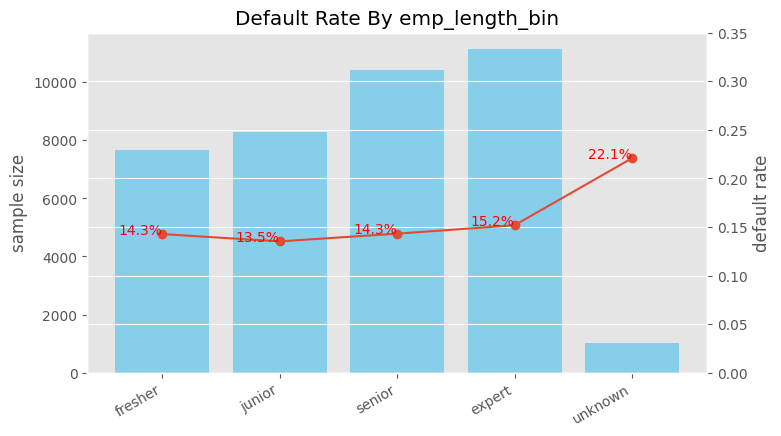

In [98]:
plot_default_rate_by(df_Q4, "emp_length_bin")

> What's your `interetation`?

> A:

> The default rate in each category of variable emp_length is quite close to each other, except for the "unknown" category, with 22.1% default rate. But it might not reliable due to the small sample size. Other than that, emp_length doesn't have much distinguishing power.

#### Question 5.1. A quick glance on Loan Purpose (`purpose`) using your first function :)

### Question 5. Segmented Univariate Analysis



In [99]:
def plot_default_rate(data, var):
    var_default_rate = (data.
                           groupby((var))['loan_status'].
                           apply(lambda x: (x == 1).mean()*100).
                           reset_index())
    
    plt.figure(figsize=(8,6))
    plt.bar(var_default_rate[(var)], var_default_rate['loan_status'])
    plt.title(f"Default Rates Across {var}")
    plt.xlabel((var))
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

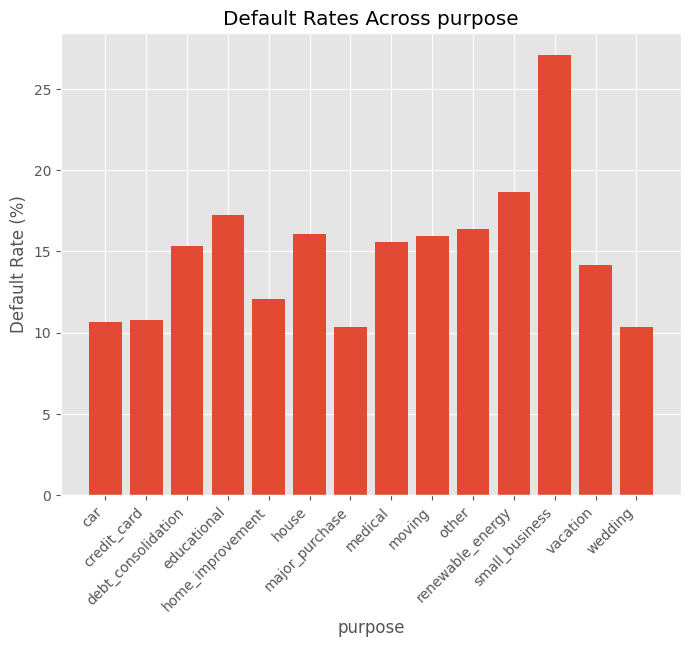

In [100]:
plot_default_rate(df_Q4, 'purpose')

`Interpretation`?

Small business - highest risk, likely due to uncertainty of business outcomes.
Purposes that have smaller comments tend to have lower default rates.

#### Question 5.2. Now let's segment the loan applications across the purpose of the loan, since that is a variable affecting many other variables - the type of applicant, interest rate, income, and finally the default rate. 

> Let's take a look at the number of loans for each type (purpose) of the loan.

In [101]:
df_Q4['purpose'].value_counts()

purpose
debt_consolidation    18055
credit_card            5027
other                  3865
home_improvement       2875
major_purchase         2150
small_business         1754
car                    1499
wedding                 926
medical                 681
moving                  576
vacation                375
house                   367
educational             325
renewable_energy        102
Name: count, dtype: int64

> Please analyze the top 4 types of loans based on purpose

#### Let's filter the df for the 4 types of loans mentioned above

In [102]:
top4 = df_Q4['purpose'].value_counts().head(4).index
top4

Index(['debt_consolidation', 'credit_card', 'other', 'home_improvement'], dtype='object', name='purpose')

In [103]:
q5p2 = df_Q4[df_Q4['purpose'].isin(top4)]

#### Visualize the number of loans by purpose 

<Axes: xlabel='purpose'>

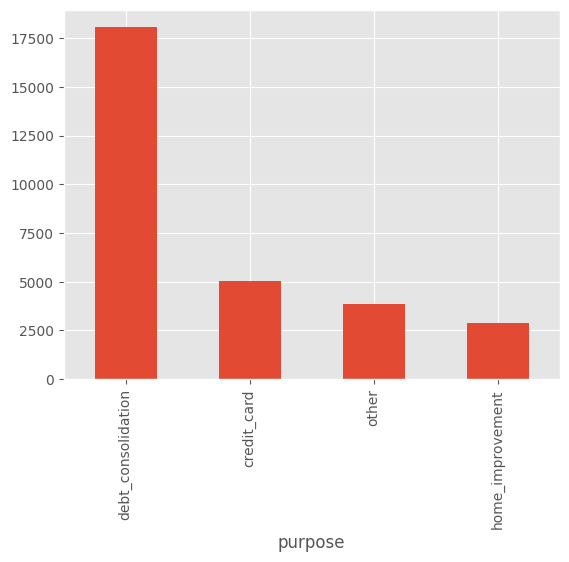

In [104]:
q5p2['purpose'].value_counts().plot(kind='bar')

> let's now compare the default rates (`loan_status`) across two types of categorical variables;
> - `purpose` of loan (constant)
> - another categorical variable (which changes)

In [105]:
q5p2.groupby(['term', 'purpose'])['loan_status'].mean()

term       purpose           
36 months  credit_card           0.077732
           debt_consolidation    0.111873
           home_improvement      0.098605
           other                 0.131931
60 months  credit_card           0.239316
           debt_consolidation    0.263607
           home_improvement      0.178392
           other                 0.301238
Name: loan_status, dtype: float64

> You should be able to write your own function which takes a categorical variable and plots the default rate segmented by purpose.

> Please **create your function** named `plot_segmented`

In [106]:
def plot_segmented(var):

    df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()
    pivot_df = df.pivot(index = (var), columns = 'purpose', values = 'loan_status')

    ax = pivot_df.plot(kind = 'bar', figsize = (8, 6))
    ax.set_xlabel((var))
    ax.set_ylabel('Default Rate (%)')
    ax.set_title(f'Default Rates by {var} and Purpose')
    ax.legend(title='Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

> Let's use the function to see if there's differences in the term.

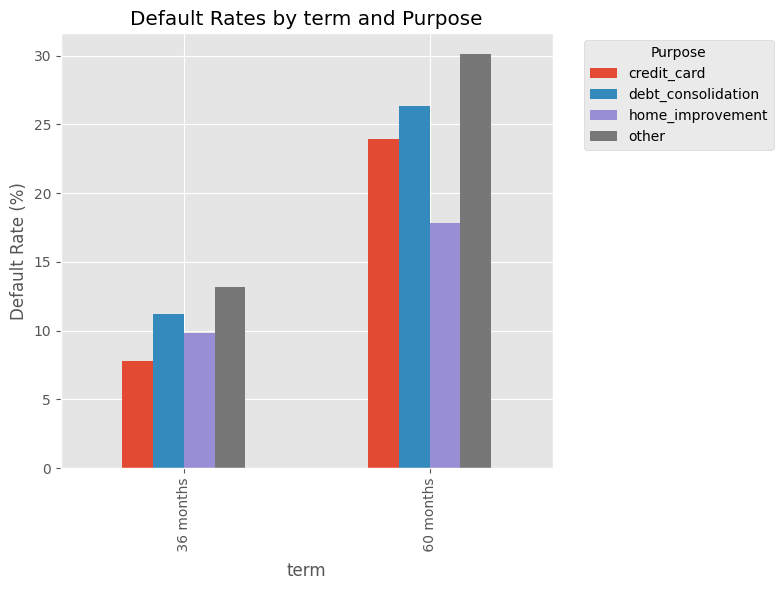

In [107]:
plot_segmented('term')

#### Grade of Loan (`grade`)

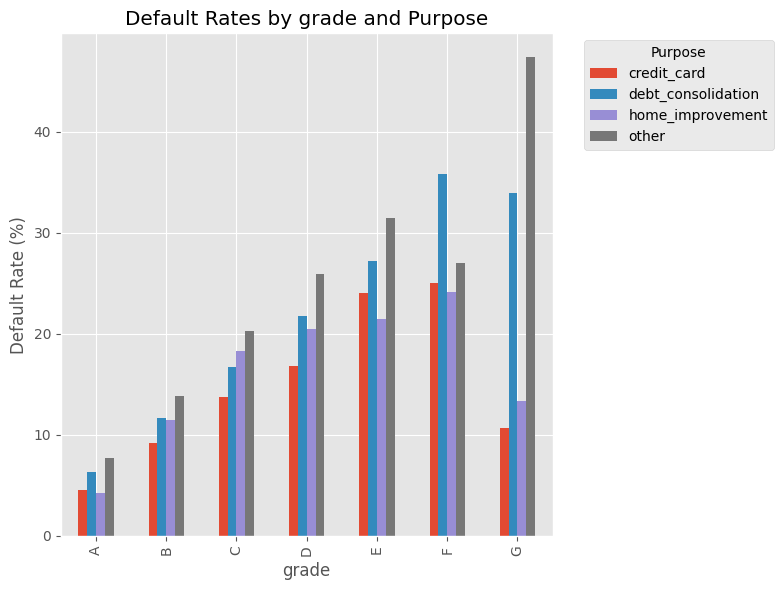

In [108]:
plot_segmented('grade')

#### home ownership(`home_ownership`)

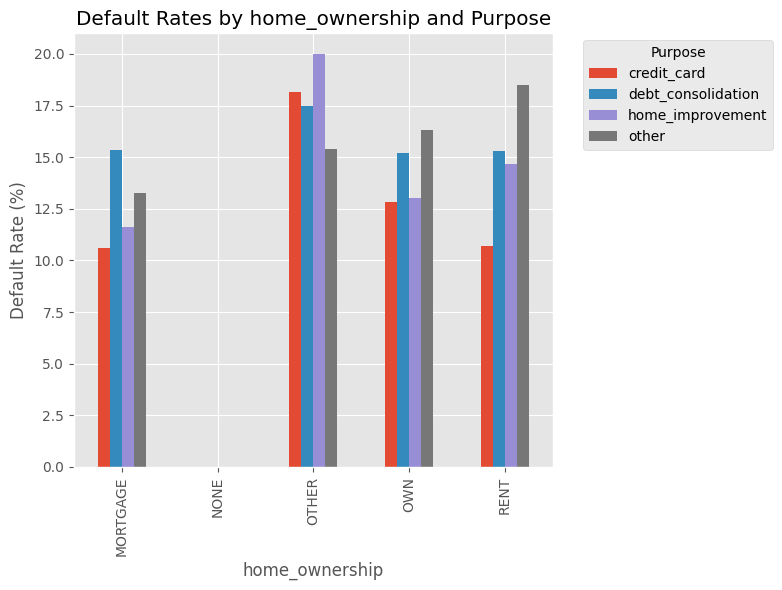

In [109]:
plot_segmented('home_ownership')

#### `year`

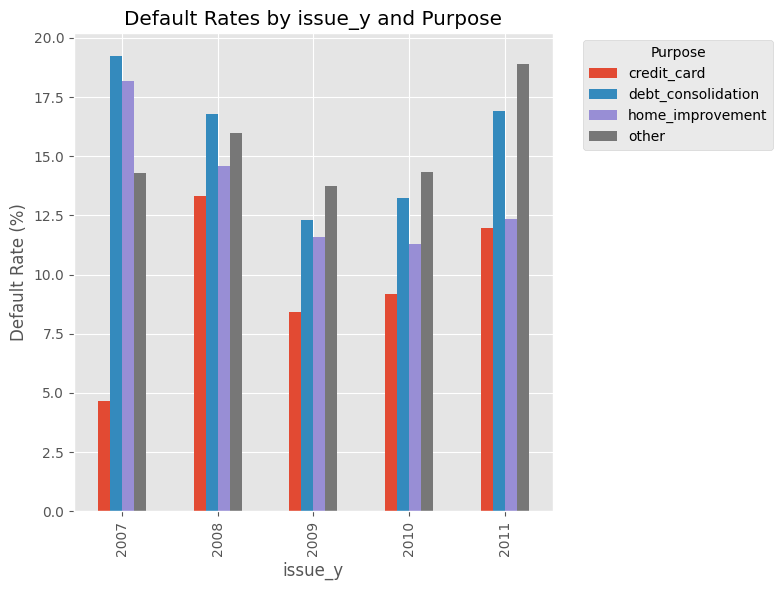

In [110]:
plot_segmented('issue_y')

#### `emp_length`

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


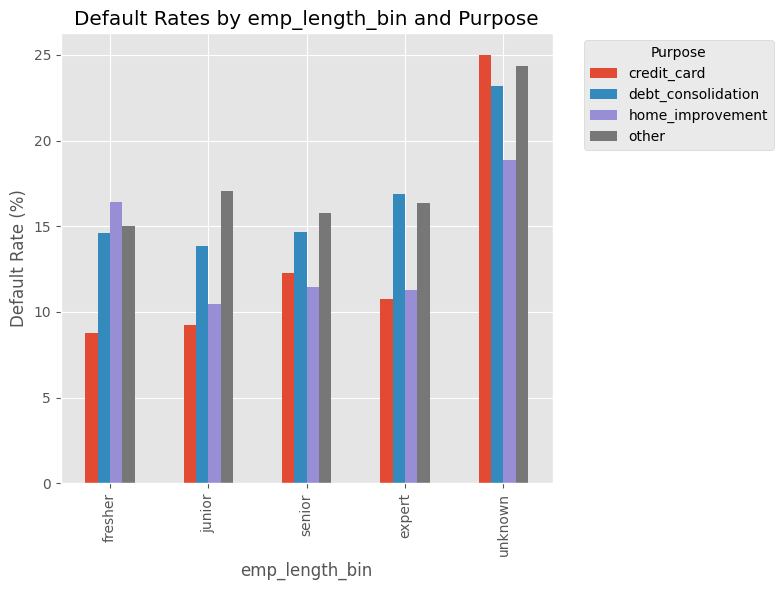

In [111]:
plot_segmented('emp_length_bin')

> Loan Amount (`loan_amnt`) 

> How's the pattern compared with loan purposes?

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


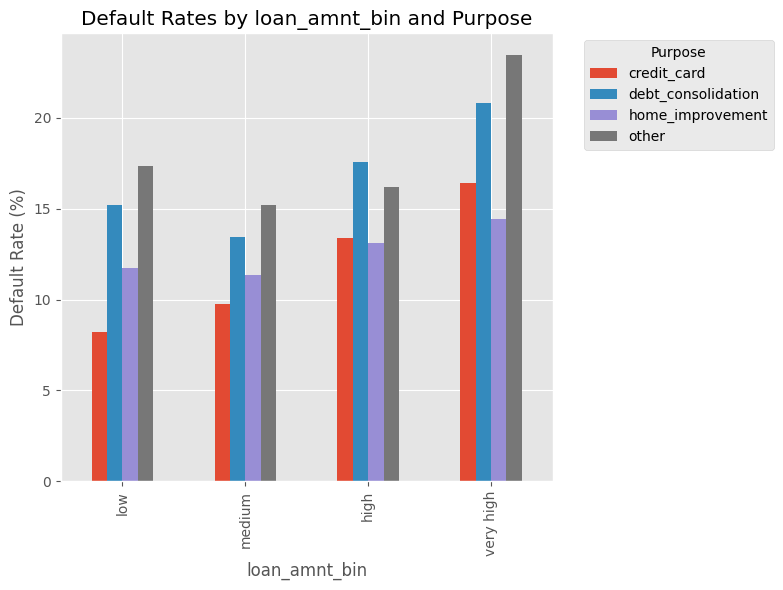

In [112]:
plot_segmented('loan_amnt_bin')

> interest rate (`int_rate`)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


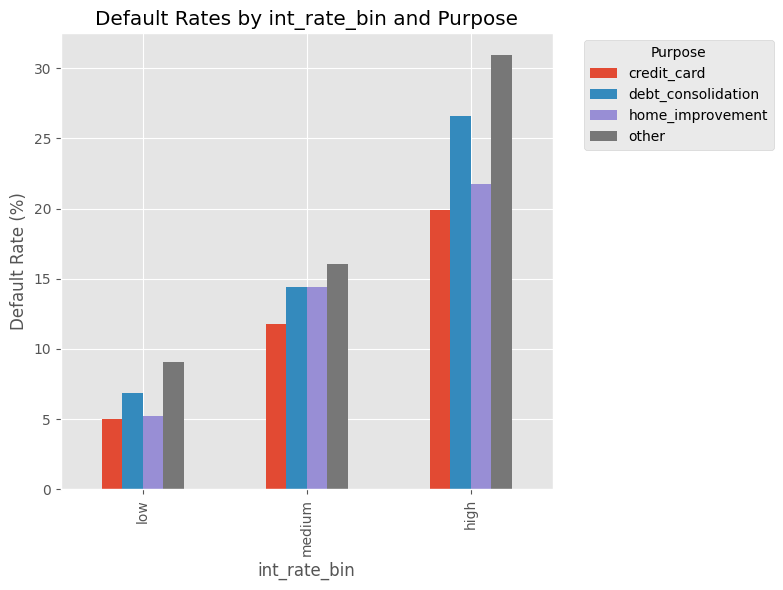

In [113]:
plot_segmented('int_rate_bin')

> `installment`

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


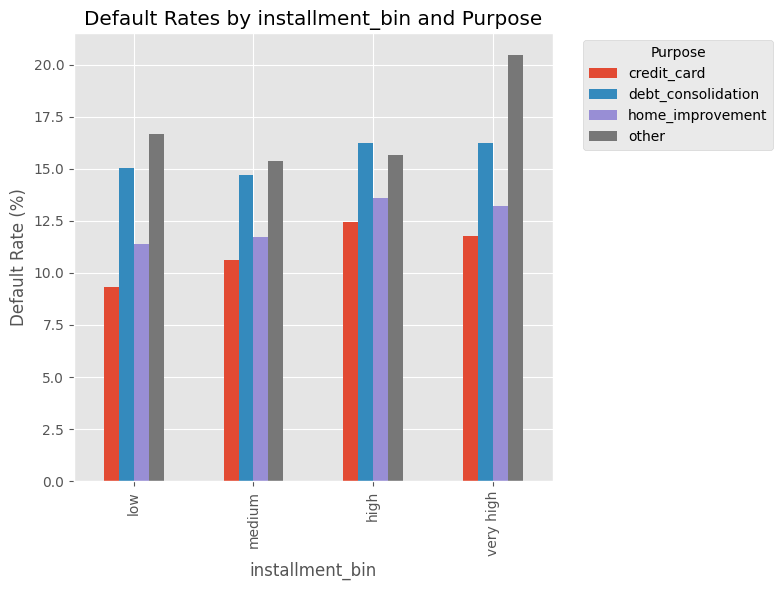

In [114]:
plot_segmented('installment_bin')

> debt-to-income (`dti`) ratio

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


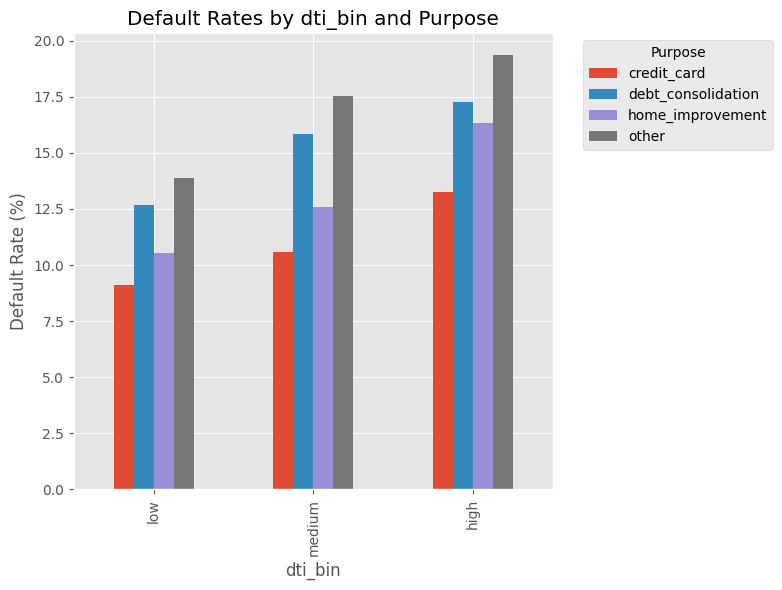

In [115]:
plot_segmented('dti_bin')

> Let's have a look at the role of `annual_income`

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1323638865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby([(var), 'purpose'])['loan_status'].mean().mul(100).reset_index()


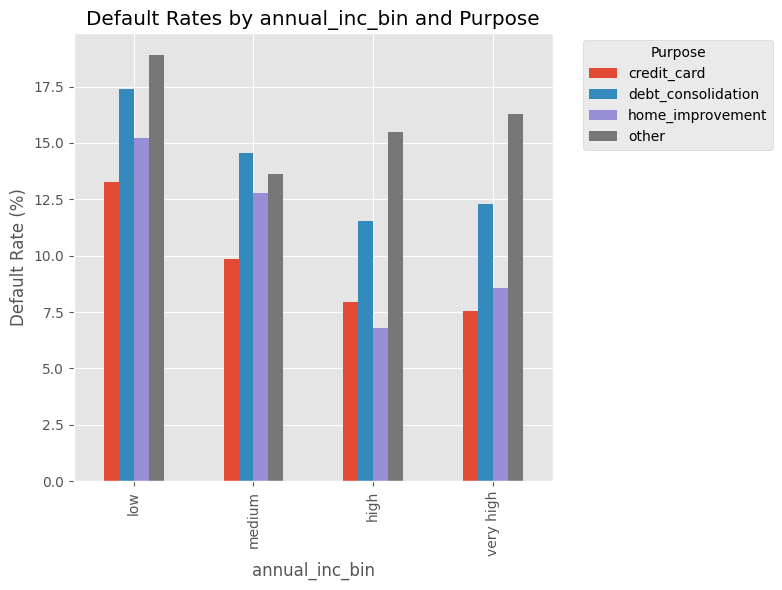

In [116]:
plot_segmented('annual_inc_bin')

> A good way to quantify the effect of a categorical variable on default rate is to see `how much does the default rate vary across the categories`. 

> Let's see an example using `annual_inc` as the categorical variable.

> How would you examine the variation of default rate across `annual_inc`?

In [117]:
q5p2.groupby('annual_inc_bin')['loan_status'].mean().mul(100).sort_values()

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/4132326820.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q5p2.groupby('annual_inc_bin')['loan_status'].mean().mul(100).sort_values()


annual_inc_bin
high         10.517903
very high    11.198600
medium       13.463197
low          16.831343
Name: loan_status, dtype: float64

#### Question 5.3 Write a function which takes in a categorical variable and computed the average default rate across the categories.

> You can also compute the `difference between the highest and the lowest default rate` across the categories, which is a decent metric indicating the effect of the varaible on default rate.

> Please create your own function named `diff_rate`.

In [118]:
def diff_rate(var):

    df = q5p2.groupby((var))['loan_status'].mean().mul(100).reset_index()

    max = df['loan_status'].max() 
    min = df['loan_status'].min() 
    diff = max - min

    return df, diff, max, min

> Please use the function and draw some insights :)

In [119]:
var = "annual_inc_bin"

df, diff, max, min = diff_rate(var)

print(f"\nDefault df by {var}:")
print(df)
print(f"\nDifference between highest and lowest default rate: {diff:.2f}%")



Default df by annual_inc_bin:
  annual_inc_bin  loan_status
0            low    16.831343
1         medium    13.463197
2           high    10.517903
3      very high    11.198600

Difference between highest and lowest default rate: 6.31%


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1271800588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby((var))['loan_status'].mean().mul(100).reset_index()


> Thus, there is a ***`??%`*** increase in default rate as you go from high to low annual income. 

##### You might want to compute this difference for all the variables and roughly identify the ones that affect default rate the most.

In [120]:
vars = [
    'annual_inc_bin',
    'grade',
    'term',
    'home_ownership',
    'verification_status',
    'issue_y',
    'issue_m',
    'loan_amnt_bin',
    'funded_amnt_bin', 
    'int_rate_bin',
    'dti_bin',
    'installment_bin',
    'emp_length_bin'
]

In [121]:
results = []

for var in vars:
    df, diff, max, min = diff_rate(var)
    results.append({
        'variable': var,
        'max_rate': max,
        'min_rate': min,
        'diff': diff
    })

results_df = pd.DataFrame(results).sort_values(by='diff', ascending=False)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1271800588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby((var))['loan_status'].mean().mul(100).reset_index()
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1271800588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = q5p2.groupby((var))['loan_status'].mean().mul(100).reset_index()
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_81638/1271800588.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

In [122]:
results_df.sort_values(by='diff', ascending=False)

,variable,max_rate,min_rate,diff
1,grade,32.780612,5.895256,26.885356
9,int_rate_bin,25.821596,6.606806,19.214790
3,home_ownership,17.391304,0.000000,17.391304
2,term,25.504537,10.722403,14.782134
12,emp_length_bin,23.200000,13.185771,10.014229
7,loan_amnt_bin,19.571865,12.801242,6.770623
0,annual_inc_bin,16.831343,10.517903,6.313440
8,funded_amnt_bin,18.804292,12.889725,5.914568
10,dti_bin,16.696945,12.071300,4.625645
6,issue_m,16.242038,11.996018,4.246020


### Variables in the Dataset

- `acc_now_delinq`	The number of accounts on which the borrower is now delinquent.
- `acc_open_past_24mths`	Number of trades opened in past 24 months.
- addr_state`	The state provided by the borrower in the loan application
- `all_util`	Balance to credit limit on all trades
- `annual_inc`	The self-reported annual income provided by the borrower during registration.
- `annual_inc_joint`	The combined self-reported annual income provided by the co-borrowers during registration
- `application_type`	Indicates whether the loan is an individual application or a joint application with two co-borrowers
- `avg_cur_bal`	Average current balance of all accounts
- `bc_open_to_buy`	Total open to buy on revolving bankcards.
- `bc_util`	Ratio of total current balance to high credit/credit limit for all bankcard accounts.
- `chargeoff_within_12_mths`	Number of charge-offs within 12 months
- `collection_recovery_fee`	post charge off collection fee
- `collections_12_mths_ex_med`	Number of collections in 12 months excluding medical collections
- `delinq_2yrs`	The number of 30+ days past-due incidences of delinquency in the borrower's credit file for the past 2 years
- `delinq_amnt`	The past-due amount owed for the accounts on which the borrower is now delinquent.
- `desc`	Loan description provided by the borrower
- `dti`	A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
- `dti_joint`	A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income
- `earliest_cr_line`	The month the borrower's earliest reported credit line was opened
- `emp_length`	Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 
- `emp_title`	The job title supplied by the Borrower when applying for the loan.*
- `fico_range_high`	The upper boundary range the borrower’s FICO at loan origination belongs to.
- `fico_range_low`	The lower boundary range the borrower’s FICO at loan origination belongs to.
- `funded_amnt`	The total amount committed to that loan at that point in time.
- `funded_amnt_inv`	The total amount committed by investors for that loan at that point in time.
- `grade`	LC assigned loan grade
- `home_ownership`	The home ownership status provided by the borrower during registration. Our values are: RENT, OWN, MORTGAGE, OTHER.
- `id`	A unique LC assigned ID for the loan listing.
- `il_util`	Ratio of total current balance to high credit/credit limit on all install acct
- `initial_list_status`	The initial listing status of the loan. Possible values are – W, F
- `inq_fi`	Number of personal finance inquiries
- `inq_last_12m`	Number of credit inquiries in past 12 months
- `inq_last_6mths`	The number of inquiries in past 6 months (excluding auto and mortgage inquiries)
- `installment`	The monthly payment owed by the borrower if the loan originates.
- `int_rate`	Interest Rate on the loan
- `issue_d`	The month which the loan was funded
- `last_credit_pull_d`	The most recent month LC pulled credit for this loan
- `last_fico_range_high`	The upper boundary range the borrower’s last FICO pulled belongs to.
- `last_fico_range_low`	The lower boundary range the borrower’s last FICO pulled belongs to.
- `last_pymnt_amnt`	Last total payment amount received
- `last_pymnt_d`	Last month payment was received
- `loan_amnt`	The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- `loan_status`	Current status of the loan
- `max_bal_bc`	Maximum current balance owed on all revolving accounts
- `member_id`	A unique LC assigned Id for the borrower member.
- `mo_sin_old_il_acct`	Months since oldest bank installment account opened
- `mo_sin_old_rev_tl_op`	Months since oldest revolving account opened
- `mo_sin_rcnt_rev_tl_op`	Months since most recent revolving account opened
- `mo_sin_rcnt_tl`	Months since most recent account opened
- `mort_acc`	Number of mortgage accounts.
- `mths_since_last_delinq`	The number of months since the borrower's last delinquency.
- `mths_since_last_major_derog`	Months since most recent 90-day or worse rating
- `mths_since_last_record`	The number of months since the last public record.
- `mths_since_rcnt_il`	Months since most recent installment accounts opened
- `mths_since_recent_bc`	Months since most recent bankcard account opened.
- `mths_since_recent_bc_dlq`	Months since most recent bankcard delinquency
- `mths_since_recent_inq`	Months since most recent inquiry.
- `mths_since_recent_revol_delinq`	Months since most recent revolving delinquency.
- `next_pymnt_d`	Next scheduled payment date
- `num_accts_ever_120_pd`	Number of accounts ever 120 or more days past due
- `num_actv_bc_tl`	Number of currently active bankcard accounts
- `num_actv_rev_tl`	Number of currently active revolving trades
- `num_bc_sats`	Number of satisfactory bankcard accounts
- `num_bc_tl`	Number of bankcard accounts
- `num_il_tl`	Number of installment accounts
- `num_op_rev_tl`	Number of open revolving accounts
- `num_rev_accts`	Number of revolving accounts
- `num_rev_tl_bal_gt_0`	Number of revolving trades with balance >0
- `num_sats`	Number of satisfactory accounts
- `num_tl_120dpd_2m`	Number of accounts currently 120 days past due (updated in past 2 months)
- `num_tl_30dpd`	Number of accounts currently 30 days past due (updated in past 2 months)
- `num_tl_90g_dpd_24m`	Number of accounts 90 or more days past due in last 24 months
- `num_tl_op_past_12m`	Number of accounts opened in past 12 months
- `open_acc`	The number of open credit lines in the borrower's credit file.
- `open_acc_6m`	Number of open trades in last 6 months
- `open_il_12m`	Number of installment accounts opened in past 12 months
- `open_il_24m`	Number of installment accounts opened in past 24 months
- `open_il_6m`	Number of currently active installment trades
- `open_rv_12m`	Number of revolving trades opened in past 12 months
- `open_rv_24m`	Number of revolving trades opened in past 24 months
- `out_prncp`	Remaining outstanding principal for total amount funded
- `out_prncp_inv`	Remaining outstanding principal for portion of total amount funded by investors
- `pct_tl_nvr_dlq`	Percent of trades never delinquent
- `percent_bc_gt_75`	Percentage of all bankcard accounts > 75% of limit.
- `policy_code`	publicly available policy_code=1; new products not publicly available policy_code=2"
- `pub_rec`	Number of derogatory public records
- `pub_rec_bankruptcies`	Number of public record bankruptcies
- `purpose`	A category provided by the borrower for the loan request. 
- `pymnt_plan`	Indicates if a payment plan has been put in place for the loan
- `recoveries`	post charge off gross recovery
- `revol_bal`	Total credit revolving balance
- `revol_util`	Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- `sub_grade`	LC assigned loan subgrade
- `tax_liens`	Number of tax liens
- `term`	The number of payments on the loan. Values are in months and can be either 36 or 60.
- `title`	The loan title provided by the borrower
- `tot_coll_amt`	Total collection amounts ever owed
- `tot_cur_bal`	Total current balance of all accounts
- `tot_hi_cred_lim`	Total high credit/credit limit
- `total_acc`	The total number of credit lines currently in the borrower's credit file
- `total_bal_ex_mort`	Total credit balance excluding mortgage
- `total_bal_il`	Total current balance of all installment accounts
- `total_bc_limit`	Total bankcard high credit/credit limit
- `total_cu_tl`	Number of finance trades
- `total_il_high_credit_limit`	Total installment high credit/credit limit
- `total_pymnt`	Payments received to date for total amount funded
- `total_pymnt_inv`	Payments received to date for portion of total amount funded by investors
- `total_rec_int`	Interest received to date
- `total_rec_late_fee`	Late fees received to date
- `total_rec_prncp`	Principal received to date
- `total_rev_hi_lim`  	Total revolving high credit/credit limit
- `url`	URL for the LC page with listing data.
- `verification_status`	Indicates if income was verified by LC, not verified, or if the income source was verified
- `verified_status_joint`	Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified
- `zip_code`	The first 3 numbers of the zip code provided by the borrower in the loan application.

### <font color="green">"Thank you for putting your efforts into the exercise problem sets :)"</font>